In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox

In [292]:
peanut = pd.read_excel('Dry_Bean_Dataset.xlsx')

In [293]:
peanut.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [294]:
peanut['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

> Class: 
- DERMASON 
- SIRA    
- SEKER   
- HOROZ   
- CALI   
- BARBUNYA 
- BOMBAY 

In [295]:
peanut['Class'] = peanut['Class'].map({'BOMBAY':0, 'BARBUNYA':1, 'CALI':2, 'HOROZ':3, 'SEKER':4, 'SIRA':5, 'DERMASON':6})

In [296]:
peanut['Class'].value_counts()

Class
6    3546
5    2636
4    2027
3    1928
2    1630
1    1322
0     522
Name: count, dtype: int64

In [297]:
peanut.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,4
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,4
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,4
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,4
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,4


In [298]:
X = peanut.drop('Class', axis=1)
y = peanut['Class']

In [299]:
# Scaling

X_scaled = (X - X.mean()) / X.std()

In [300]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    x_train, x_test = [], []
    y_train, y_test = [], []

    for class_values in np.unique(y):
        class_idx = np.where(y == class_values)[0]

        idx = np.random.permutation(class_idx)
        split = int(len(idx) * size)

        x_train.append(X.iloc[idx[:split]])
        x_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(x_train).reset_index(drop=True)
    X_test = pd.concat(x_test).reset_index(drop=True)
    y_train = pd.concat(y_train).reset_index(drop=True)
    y_test = pd.concat(y_test).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [301]:
X_train, X_test, y_train, y_test = split_data(X, y)

In [302]:
for var in [X_train, X_test, y_train, y_test]:
    print(var.shape)

(10885, 16)
(2726, 16)
(10885,)
(2726,)


In [303]:
class Node:
    def __init__(self, point, label, left=None, right=None, axis=0):
        self.point = np.array(point)
        self.label = label
        self.left = left
        self.right = right
        self.axis = axis

class kdtree:
    def __init__(self, k_dimension):
        self.root = None
        self.k_dimension = k_dimension

    def build(self, point, label, depth=0):
        n = len(point)
        if n == 0:
            return None
        
        axis = depth % self.k_dimension

        sorted_indicies = np.argsort(point[:, axis])
        point = point[sorted_indicies]
        label = label[sorted_indicies]

        median = n // 2

        return Node(
            point = point[median],
            label = label[median],
            left = self.build(point[:median], label[:median], depth + 1),
            right = self.build(point[median+1:], label[median+1:], depth + 1),
            axis = axis 
        )

    def fit(self, X, y):
        self.root = self.build(np.array(X), np.array(y))
        return self

    def _search_nearest(self, node,target, best=None):
        if node is None:
            return best
        
        dist = np.sum((node.point - target) ** 2)

        if best is None or dist < best[0]:
            best = (dist, node.point, node.label)

        diff = target[node.axis] - node.point[point.axis]
        first = node.left if diff < 0 else node.right
        second = node.right if diff < 0 else node.left

        best = self._search_nearest(first, target, best)

        if best[0] > diff ** 2:
            best = self._search_nearest(second, target, best)

        return best

    def nearest_neighbor(self, point):
        result = self._search_nearest(self.root, np.array(point))
        return result[1], result[2]

    def _search_k_nearest(self, node, target, heap, k):
        if node is None:
            return heap

        dist = float(np.sum((node.point - target) ** 2))

        if len(heap) < k:
            heap.append((dist, node.point.copy(), node.label))
        elif dist < heap[0][0]:
            heap[0] = (dist, node.point.copy(), node.label)
            distances = np.array([h[0] for h in heap])
            sorted_indices = np.argsort(distances)[::-1]
            heap = [heap[i] for i in sorted_indices]

        diff = target[node.axis] - node.point[node.axis]
        first = node.left if diff < 0 else node.right
        second = node.right if diff < 0 else node.left

        heap = self._search_k_nearest(first, target, heap, k)

        if len(heap) < k or heap[0][0] > diff ** 2:
            heap = self._search_k_nearest(second, target, heap, k)
        
        return heap

    def k_nearest_neighbors(self, point, k=3):
        point = np.array(point, dtype=float)
        heap = self._search_k_nearest(self.root, np.array(point), [], k)

        distances = np.array([h[0] for h in heap])
        sorted_indices = np.argsort(distances)
        heap = [heap[i] for i in sorted_indices]
        
        return [(p, label) for (_, p, label) in heap]
        

In [304]:
class KNN:
    def __init__(self, n_neighbors=3):
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        # Store data as numpy arrays for fast mathematical operations
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        return self

    def predict(self, X_test):
        X_test = np.array(X_test, dtype=float)
        predictions = []
        
        for x in X_test:
            # 1. VECTORIZED DISTANCE CALCULATION
            # Calculates the squared Euclidean distance between 'x' and 
            # ALL training points simultaneously using C-level optimization.
            distances = np.sum((self.X_train - x) ** 2, axis=1)
            
            # 2. FAST PARTITIONING
            # np.argpartition is O(N) and much faster than np.argsort which is O(N log N).
            # It just pushes the 'k' smallest distances to the front of the array.
            k_indices = np.argpartition(distances, self.k)[:self.k]
            k_labels = self.y_train[k_indices]
            
            # 3. MAJORITY VOTE
            unique, counts = np.unique(k_labels, return_counts=True)
            predictions.append(unique[np.argmax(counts)])
            
        return np.array(predictions)

    def score(self, X, y):
        prediction = self.predict(X)
        return np.mean(prediction == y)

In [305]:
def SMOTE(X, y, k=5):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthethic = counts.max() - counts.min()

    synthethic_samples = []

    for _ in range(n_synthethic):
        idx = np.random.randint(0, len(minority_X))
        sample = minority_X[idx]

        distances = np.sqrt(np.sum((minority_X - sample)**2, axis=1))
        nn_indicies = np.argsort(distances)[1:k+1]
        nn_idx = np.random.choice(nn_indicies)
        neighboor = minority_X[nn_idx]

        gap = np.random.rand()
        synthethic_samples.append(sample + gap * (neighboor - sample))

    X_balanced = np.vstack((X_np, synthethic_samples))
    y_balanced = np.hstack((y_np, np.full(n_synthethic, minority_class)))
    shuffle_idx = np.random.permutation(len(y_balanced))
    
    X_smote = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_smote = pd.Series(y_balanced[shuffle_idx], name=y.name)
    
    return X_smote, y_smote

In [306]:
def noise_injection(X, y, noise_factor=0.1):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthetic = counts.max() - counts.min()

    indicies = np.random.choice(len(minority_X), n_synthetic, replace=True)
    base_sample = minority_X[indicies]

    std_devs = np.std(X_np, axis=0) * noise_factor
    noise = np.random.normal(0, std_devs, base_sample.shape)

    noisy_sample = base_sample + noise

    X_balanced = np.vstack((X_np, noisy_sample))
    y_balanced = np.hstack((y_np, np.full(n_synthetic, minority_class)))

    shuffle_idx = np.random.permutation(len(y_balanced))

    X_noise = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_noise = pd.Series(y_balanced[shuffle_idx], name=y.name)

    return X_noise, y_noise

In [307]:
X_train_smote, y_train_smote = SMOTE(X_train, y_train)

In [308]:
X_train_noise, y_train_noise = noise_injection(X_train, y_train)

In [309]:
def search_k(X_train, y_train, X_test):
    best_acc = 0
    best_k = {}
    
    for k in [3,5,7,9,11,13,15]:
        for p in [1,2]:
            model = KNN(n_neighbors=k)
            model.fit(X_train, y_train)
            acc = model.score(X_test.values, y_test)
    
            distance = 'manhattan' if p == 1 else 'euclidean'
            print(f'K: {k} - Distance: {distance} - Accuracy: {acc:.4f}')
    
            if acc > best_acc:
                best_acc = acc
                best_k = {'k':k, 'p':p}
    distance_label = 'maanhattan' if p == 1 else 'euclidean'
    print('Final')
    print(f'Best K: {best_k.get('k', 'N/A')} - Distance: {distance_label} - Accuracy: {best_acc:.4f}')

    return best_k

In [310]:
best_k = search_k(X_train, y_train, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.7348
K: 3 - Distance: euclidean - Accuracy: 0.7348
K: 5 - Distance: manhattan - Accuracy: 0.7230
K: 5 - Distance: euclidean - Accuracy: 0.7230
K: 7 - Distance: manhattan - Accuracy: 0.7267
K: 7 - Distance: euclidean - Accuracy: 0.7267
K: 9 - Distance: manhattan - Accuracy: 0.7183
K: 9 - Distance: euclidean - Accuracy: 0.7183
K: 11 - Distance: manhattan - Accuracy: 0.7197
K: 11 - Distance: euclidean - Accuracy: 0.7197
K: 13 - Distance: manhattan - Accuracy: 0.7150
K: 13 - Distance: euclidean - Accuracy: 0.7150
K: 15 - Distance: manhattan - Accuracy: 0.7146
K: 15 - Distance: euclidean - Accuracy: 0.7146
Final
Best K: 3 - Distance: euclidean - Accuracy: 0.7348


In [311]:
best_k_smote = search_k(X_train_smote, y_train_noise, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.1045
K: 3 - Distance: euclidean - Accuracy: 0.1045
K: 5 - Distance: manhattan - Accuracy: 0.1225
K: 5 - Distance: euclidean - Accuracy: 0.1225
K: 7 - Distance: manhattan - Accuracy: 0.1222
K: 7 - Distance: euclidean - Accuracy: 0.1222
K: 9 - Distance: manhattan - Accuracy: 0.1251
K: 9 - Distance: euclidean - Accuracy: 0.1251
K: 11 - Distance: manhattan - Accuracy: 0.1368
K: 11 - Distance: euclidean - Accuracy: 0.1368
K: 13 - Distance: manhattan - Accuracy: 0.1332
K: 13 - Distance: euclidean - Accuracy: 0.1332
K: 15 - Distance: manhattan - Accuracy: 0.1416
K: 15 - Distance: euclidean - Accuracy: 0.1416
Final
Best K: 15 - Distance: euclidean - Accuracy: 0.1416


In [312]:
best_k_noise = search_k(X_train_noise, y_train_noise, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.7348
K: 3 - Distance: euclidean - Accuracy: 0.7348
K: 5 - Distance: manhattan - Accuracy: 0.7223
K: 5 - Distance: euclidean - Accuracy: 0.7223
K: 7 - Distance: manhattan - Accuracy: 0.7263
K: 7 - Distance: euclidean - Accuracy: 0.7263
K: 9 - Distance: manhattan - Accuracy: 0.7179
K: 9 - Distance: euclidean - Accuracy: 0.7179
K: 11 - Distance: manhattan - Accuracy: 0.7194
K: 11 - Distance: euclidean - Accuracy: 0.7194
K: 13 - Distance: manhattan - Accuracy: 0.7146
K: 13 - Distance: euclidean - Accuracy: 0.7146
K: 15 - Distance: manhattan - Accuracy: 0.7142
K: 15 - Distance: euclidean - Accuracy: 0.7142
Final
Best K: 3 - Distance: euclidean - Accuracy: 0.7348


In [313]:
model = KNN(n_neighbors=3)
model.fit(X_train, y_train)

model_smote = KNN(n_neighbors=3)
model_smote.fit(X_train_smote, y_train_smote)

model_noise = KNN(n_neighbors=3)
model_noise.fit(X_train_noise, y_train_noise)

In [314]:
# reguler
y_pred_train = model.predict(X_train.values)
y_pred_test = model.predict(X_test.values)

# Smote
y_pred_train_smote = model_smote.predict(X_train_smote.values)
y_pred_test_smote = model_smote.predict(X_test.values)

# Noise
y_pred_train_noise = model_noise.predict(X_train_noise.values)
y_pred_test_noise = model_noise.predict(X_test.values)

In [315]:
def evaluate(y_true, y_pred, X_test, y_test,title='Train'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    classes = np.unique(y)
    n_classes = len(classes)

    accuracy = model.score(X_test.values, y_test.values)
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    precision = np.mean(precision)
    recall = np.mean(recall)
    f1 = np.mean(f1)

    print(f'Hasil Evaluasi {title}')
    print(f'Accuracy    : {accuracy:.4%}')
    print(f'Precision   : {precision:.4%}')
    print(f'Recall      : {recall:.4%}')
    print(f'F1          : {f1:.4%}')

### Rgular

In [316]:
evaluate(y_train, y_pred_train, X_train, y_train)

Hasil Evaluasi Train
Accuracy    : 85.8980%
Precision   : 86.0758%
Recall      : 86.0437%
F1          : 86.0341%


In [317]:
evaluate(y_test, y_pred_test, X_test, y_test, title='Test')

Hasil Evaluasi Test
Accuracy    : 73.4776%
Precision   : 73.4338%
Recall      : 73.0829%
F1          : 73.1776%


### Smote

In [318]:
evaluate(y_train_smote, y_pred_train_smote, X_train, y_train)

Hasil Evaluasi Train
Accuracy    : 85.8980%
Precision   : 86.1340%
Recall      : 86.0437%
F1          : 86.0633%


In [319]:
evaluate(y_test, y_pred_test_smote, X_test, y_test, title="Testt")

Hasil Evaluasi Testt
Accuracy    : 73.4776%
Precision   : 73.4338%
Recall      : 73.0829%
F1          : 73.1776%


### Noise

In [320]:
evaluate(y_train_noise, y_pred_train_noise, X_test, y_test)

Hasil Evaluasi Train
Accuracy    : 73.4776%
Precision   : 86.1340%
Recall      : 86.0437%
F1          : 86.0633%


In [321]:
evaluate(y_test, y_pred_test_noise, X_test, y_test, title='Test')

Hasil Evaluasi Test
Accuracy    : 73.4776%
Precision   : 73.4338%
Recall      : 73.0829%
F1          : 73.1776%


In [322]:
def confusion_matrix(y_train, y_pred_train, y_test, y_pred_test, title=''):
    classes = np.unique(y)
    n_classes = len(classes)

    fig, axes = plt.subplots(1,2, figsize=(8,6))
    plt.suptitle(f'Evaluasi Data {title}', fontsize=26)
    fig.supxlabel('Prediksi')
    fig.supylabel('Aktual')
    

    cm_train = np.zeros((n_classes, n_classes))
    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm_train[i,j] = np.sum((y_train == c_true) * (y_pred_train == c_pred))
    sns.heatmap(cm_train, annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar=False)

    cm_test = np.zeros((n_classes, n_classes))
    for a, a_true in enumerate(classes):
        for b, a_pred in enumerate(classes):
            cm_test[a,b] = np.sum((y_test == a_true) * (y_pred_test == a_pred))
    sns.heatmap(cm_test, annot=True, fmt='.0f', cmap='Blues', ax=axes[1], cbar=False)

    plt.tight_layout()
    plt.show()

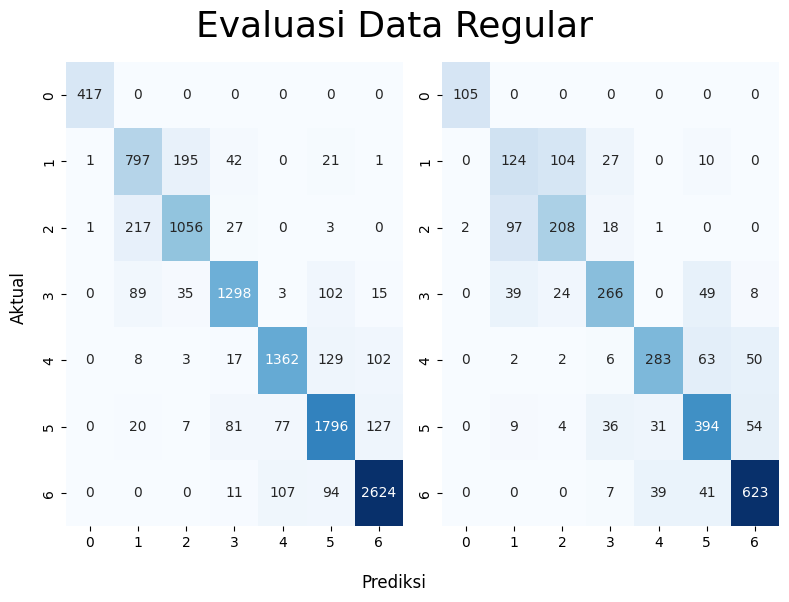

In [323]:
confusion_matrix(y_train, y_pred_train, y_test, y_pred_test, title='Regular')

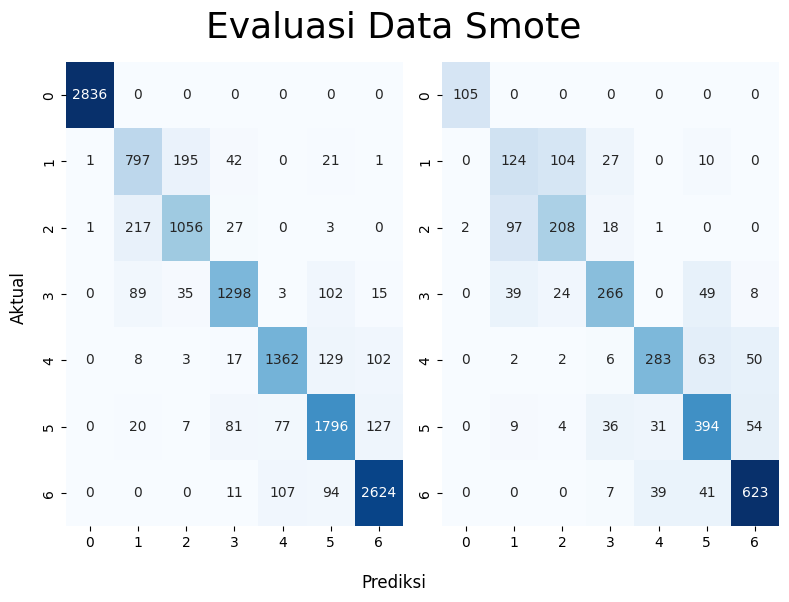

In [324]:
confusion_matrix(y_train_smote, y_pred_train_smote, y_test, y_pred_test_smote, title='Smote')

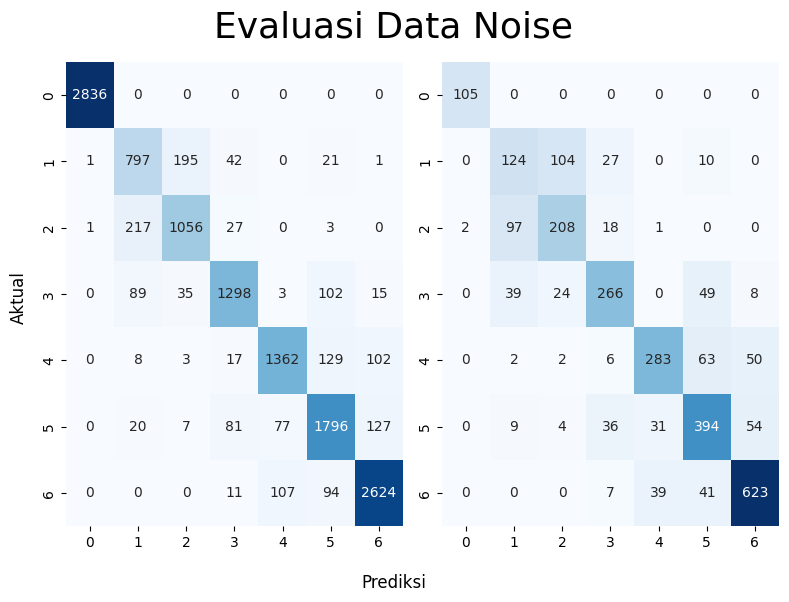

In [325]:
confusion_matrix(y_train_noise, y_pred_train_noise, y_test, y_pred_test_noise, title='Noise')

In [331]:
# Fungsi Visualisasi Poin Kesalahan

def incorrect_point(y_true, y_pred, X, title='Train'):
    incorrect = y_true != y_pred
    correct = ~incorrect

    n_incorrect = np.sum(incorrect)
    n_correct = np.sum(correct)

    plt.figure(figsize=(10,8))
    plt.scatter(X[incorrect, 0], X[incorrect, 1], color='red', label=f'Salah ({n_incorrect})')
    plt.scatter(X[correct, 0], X[correct, 1], color='blue', label=f'Benar ({n_correct})')
    plt.title(f'Point Kesalahan {title}')
    plt.legend()
    plt.grid()
    plt.show()

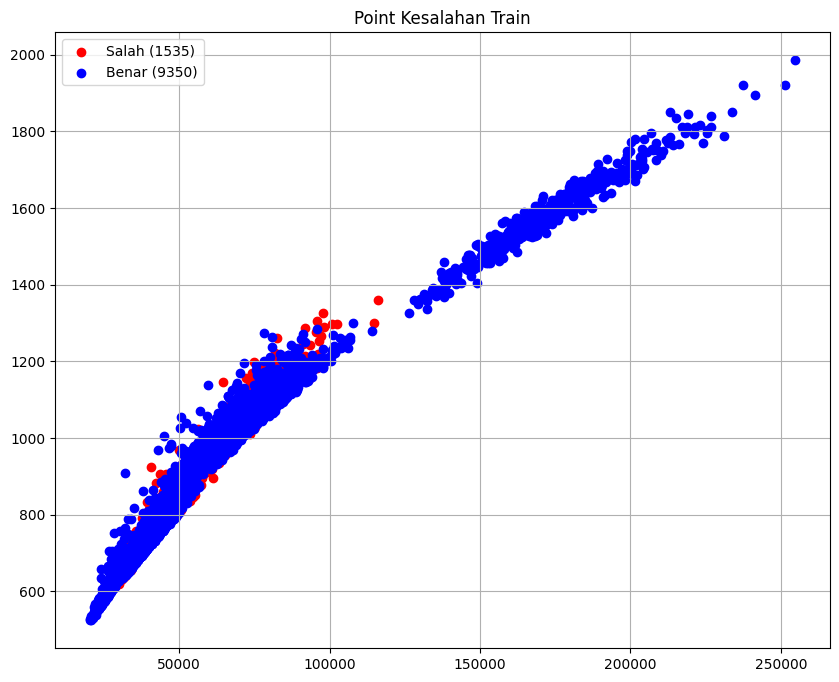

In [333]:
incorrect_point(y_train, y_pred_train, X_train.values)

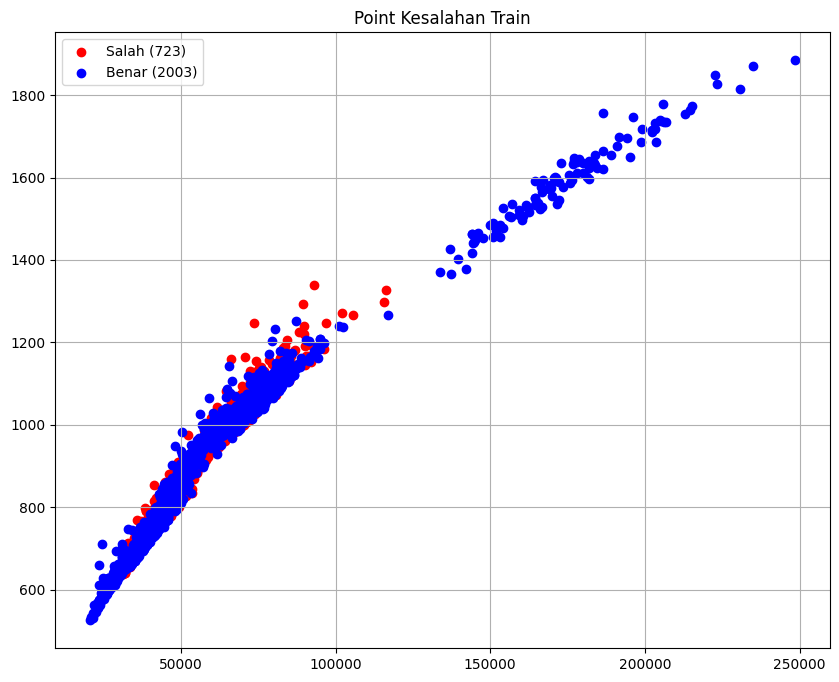

In [334]:
incorrect_point(y_test, y_pred_test, X_test.values)

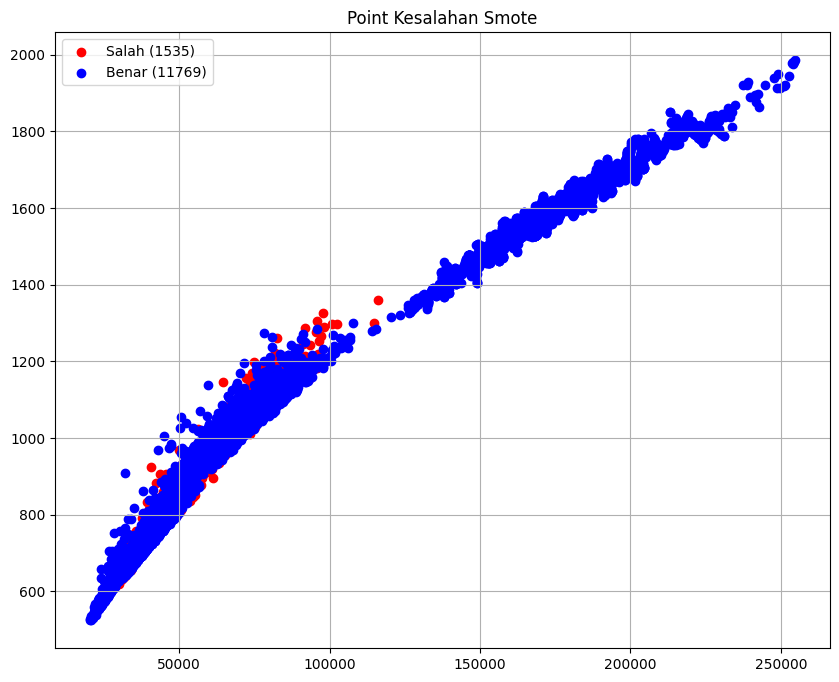

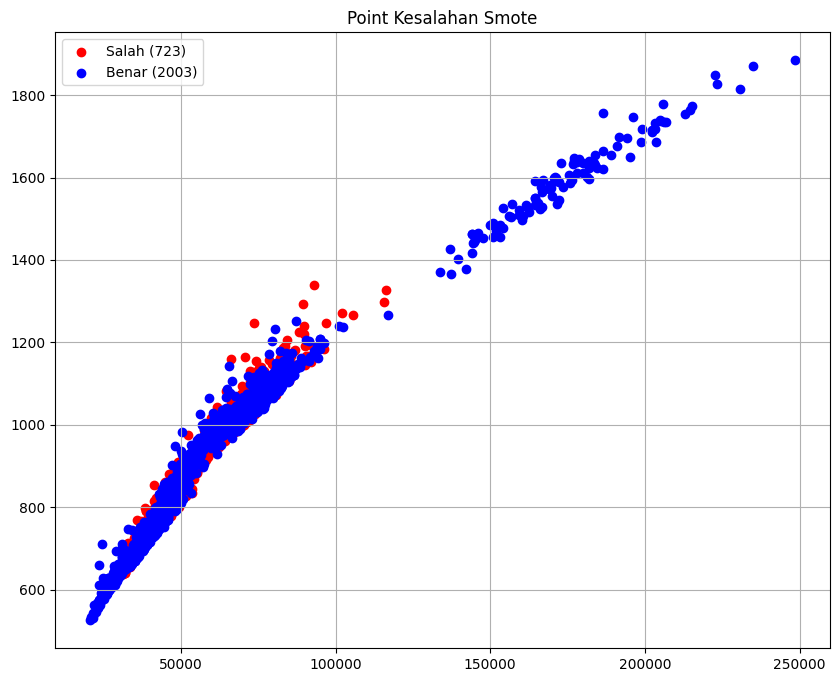

In [338]:
incorrect_point(y_train_smote, y_pred_train_smote, X_train_smote.values, title='Smote')
incorrect_point(y_test, y_pred_test_smote, X_test.values, title='Smote')

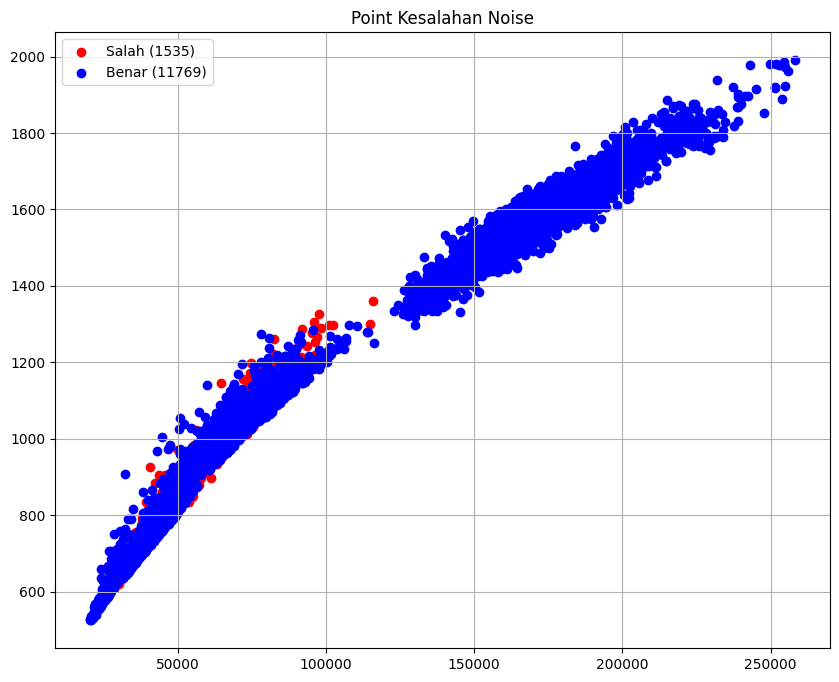

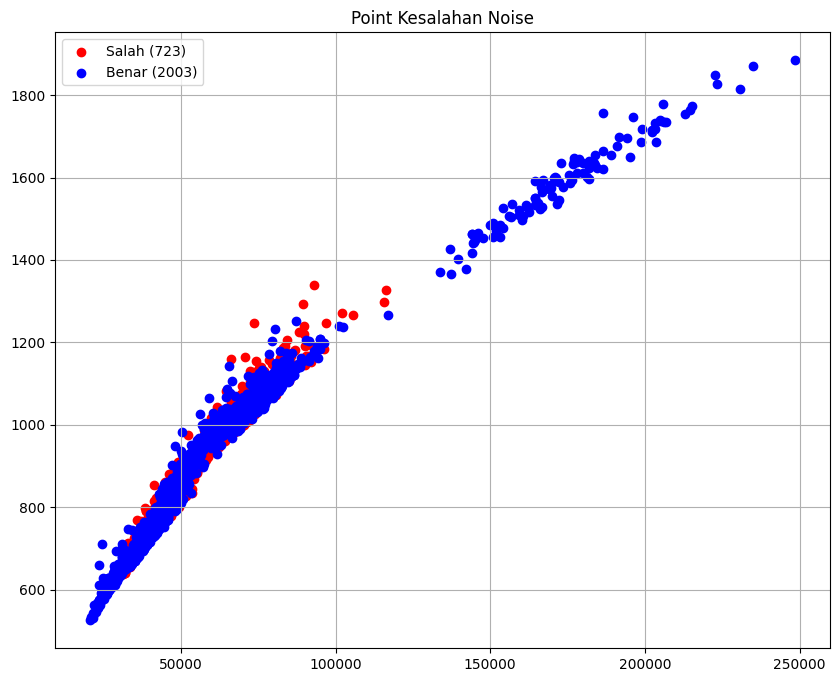

In [ ]:
incorrect_point(y_train_noise, y_pred_train_noise, X_train_noise.values, title='Noise')
incorrect_point(y_test, y_pred_test_noise, X_test.values, title='Noise')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary_2d(model, X, y, feature_indices=[0, 1], 
                              resolution=0.02, title="KNN Decision Boundary"):
 
    
    # Extract the 2 features for visualization
    X_vis = X[:, feature_indices]
    
    # Create mesh grid
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))
    
    # Create full feature vectors for prediction (mean for other features)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # For prediction, we need all 16 features
    # Use mean values for non-visualized features
    X_mean = np.mean(X, axis=0)
    
    # Build full feature vectors
    X_full = np.tile(X_mean, (grid_points.shape[0], 1))
    X_full[:, feature_indices[0]] = grid_points[:, 0]
    X_full[:, feature_indices[1]] = grid_points[:, 1]
    
    # Predict on grid
    Z = model.predict(X_full)
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 8))
    
    # Contour plot for decision regions
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA', '#FFAAFF'][:len(np.unique(y))])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF'][:len(np.unique(y))])
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
    
    # Scatter plot of training points
    scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap=cmap_bold, 
                         edgecolor='k', s=50, alpha=0.8)
    
    plt.xlabel(f'Feature {feature_indices[0]}')
    plt.ylabel(f'Feature {feature_indices[1]}')
    plt.title(f'{title}\n(k={model.k}, Features {feature_indices[0]} vs {feature_indices[1]})')
    plt.colorbar(scatter, label='Class')
    plt.tight_layout()
    plt.show()

# Usage with your model
plot_decision_boundary_2d(model, X_train, y_train, feature_indices=peanut['Area', 'Perimeter'])  # Area vs Perimeter
plot_decision_boundary_2d(model, X_train, y_train, feature_indices=[2, 3])  # Major vs Minor Axis

TypeError: cannot use 'list' as a dict key (unhashable type: 'list')

In [348]:
def pca_2d(X):
    """Simple PCA to 2D using numpy only."""
    # Center the data
    X_centered = X - np.mean(X, axis=0)
    
    # Covariance matrix
    cov = np.cov(X_centered.T)
    
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    
    # Sort by eigenvalues (descending)
    idx = eigenvalues.argsort()[::-1]
    eigenvectors = eigenvectors[:, idx]
    
    # Project to 2D
    X_pca = X_centered @ eigenvectors[:, :2]
    
    return X_pca, eigenvectors[:, :2]

def plot_pca_decision_boundary(model, X, y, resolution=0.02):
    """Plot decision boundary in PCA-reduced 2D space."""
    
    # Reduce to 2D
    X_pca, components = pca_2d(X)
    
    # Create grid in PCA space
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))
    
    # Convert grid back to original space for prediction
    grid_pca = np.c_[xx.ravel(), yy.ravel()]
    grid_original = grid_pca @ components.T + np.mean(X, axis=0)
    
    # Predict
    Z = model.predict(grid_original)
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 8))
    
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'][:len(np.unique(y))])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'][:len(np.unique(y))])
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=cmap_bold,
                         edgecolor='k', s=50, alpha=0.8)
    
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title(f'KNN Decision Boundary (k={model.k}) - PCA Projection')
    plt.colorbar(scatter)
    plt.tight_layout()
    plt.show()

# Usage
plot_pca_decision_boundary(model, X_train.values, y_train.values)

MemoryError: Unable to allocate 32.8 TiB for an array with shape (267283, 16858558) and data type float64

In [ ]:
feature = X.columns
n_feature = len(feature)

def submit():
    try:
        input_data = []
        for entry in entries:
            value = float(entry.get())
            input_data.append(value)

        input_df = pd.DataFrame([input_data], columns=feature)
        input_scaled = (input_df - X_before.mean()) / X_before.std()
        prediction = model_noise.predict(input_scaled.values)
        messagebox.showinfo('Prediksi Model', f'Model Menebak Kacang: {prediction}')
    except ValueError:
        messagebox.showerror('Input Error', 'Masukan Value Yang Benar ⚠️')
        
root = tk.Tk()
root.configure(bg='#9ECFD4')
root.title('Prediksi Jenis Kacang')
entries = []

title_label = tk.Label(root, text='Prediksi Jenis Kacang', font=('Arial', 26, 'bold'), bg='#9ECFD4')
title_label.grid(row=0, column=0, columnspan=2, padx=25, pady=10)
for i, col in enumerate(feature):
    label = tk.Label(root, text=f'{col}:', bg='#9ECFD4')
    label.grid(row=i+1, column=0, padx=20, pady=5, sticky='w')

    entry = tk.Entry(bg='#7db0b5')
    entry.grid(row=i+1, column=1, padx=20, pady=5)
    entries.append(entry)

submit_btn = tk.Button(root, text='Prediksi', command=submit, bg='#B8DB80')
submit_btn.grid(row=n_feature+1, column=0, columnspan=2, pady=20, ipady=5)

root.mainloop()